<a href="https://colab.research.google.com/github/adit-codez/part-3-nlp-sequence-modeling/blob/main/notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Part 3: NLP and Sequence Modeling Mini Project
## Customer Support Ticket Sentiment Analysis

This notebook walks through a complete NLP pipeline on a customer support ticket dataset, covering text preprocessing, vectorization, baseline classification, sequence model design, and a reflection on attention & transformers.

## 0. Imports & Setup

In [1]:
import re, string, math, json, warnings
from collections import Counter
from io import StringIO

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, accuracy_score)
from sklearn.preprocessing import LabelEncoder

warnings.filterwarnings("ignore")
np.random.seed(42)
print("All imports successful")

All imports successful


## Task 1: Dataset Understanding

We load the customer support ticket dataset containing messages from various channels (chat, phone, email, social, app) labelled with sentiment: **positive**, **neutral**, or **negative**.

In [2]:
DATASET_LINES = [
    "ticket_id\tchannel\tcustomer_message\tsentiment_label\tword_count\turgent_flag",
    "TKT00001\tchat\tI need information about the payment process. My ticket number is 78732. Please respond as soon as possible.\tneutral\t18\t1",
    "TKT00002\tphone\tI need information about the payment process.\tneutral\t7\t0",
    "TKT00003\temail\tThe refund process was fast and convenient. I appreciate the quick response.\tpositive\t12\t0",
    "TKT00004\tsocial\tMy refund is still pending and this experience is frustrating. My ticket number is 33927.\tnegative\t15\t1",
    "TKT00005\tchat\tPlease tell me how to update my account details.\tneutral\t9\t0",
    "TKT00006\tsocial\tI need help finding the invoice for my last order. Please respond as soon as possible.\tneutral\t16\t1",
    "TKT00007\tchat\tI am satisfied with the plan and would recommend it to others. My ticket number is 99198.\tpositive\t17\t0",
    "TKT00008\tchat\tI want to understand the warranty terms for this product.\tneutral\t10\t0",
    "TKT00009\tphone\tI need help finding the invoice for my last order.\tneutral\t10\t0",
    "TKT00010\tphone\tMy refund is still pending and this experience is frustrating.\tnegative\t10\t0",
    "TKT00011\tphone\tGreat service and clear communication from the support team.\tpositive\t9\t0",
    "TKT00012\tsocial\tI like the new video call and it is easy to use. I appreciate the quick response.\tpositive\t17\t0",
    "TKT00013\tsocial\tYour support team resolved my issue quickly. Thank you. I appreciate the quick response.\tpositive\t14\t0",
    "TKT00014\tphone\tI am satisfied with the plan and would recommend it to others. My ticket number is 57739. I appreciate the quick response.\tpositive\t22\t0",
    "TKT00015\tchat\tI have raised multiple tickets but nobody has fixed the problem. Please respond as soon as possible.\tnegative\t17\t1",
    "TKT00016\temail\tI am satisfied with the plan and would recommend it to others.\tpositive\t12\t0",
    "TKT00017\temail\tBilling is incorrect and I was charged twice this month. My ticket number is 91365.\tnegative\t15\t0",
    "TKT00018\temail\tThe subscription keeps failing and support has not resolved my issue.\tnegative\t11\t0",
    "TKT00019\tapp\tCan someone explain the difference between the plans? Please respond as soon as possible.\tneutral\t14\t1",
    "TKT00020\tchat\tThe app crashes whenever I try to use video call.\tnegative\t10\t1",
    "TKT00021\tsocial\tI am satisfied with the plan and would recommend it to others.\tpositive\t12\t0",
    "TKT00022\tphone\tI am checking if there is any scheduled maintenance today. Please respond as soon as possible.\tneutral\t16\t1",
    "TKT00023\tsocial\tCan you confirm whether my ticket has been assigned?\tneutral\t9\t0",
    "TKT00024\tapp\tMy refund is still pending and this experience is frustrating.\tnegative\t10\t0",
    "TKT00025\tchat\tThe mobile app is working well and I am happy with the service. My ticket number is 50218.\tpositive\t18\t0",
    "TKT00026\temail\tI need information about the payment process.\tneutral\t7\t0",
    "TKT00027\tsocial\tI am satisfied with the plan and would recommend it to others.\tpositive\t12\t0",
    "TKT00028\tsocial\tBilling is incorrect and I was charged twice this month. My ticket number is 78132.\tnegative\t15\t1",
    "TKT00029\tapp\tI am checking if there is any scheduled maintenance today.\tneutral\t10\t0",
    "TKT00030\tchat\tThe response from the team was helpful and professional. My ticket number is 77543.\tpositive\t14\t0",
    "TKT00031\temail\tThe response from the team was helpful and professional. My ticket number is 32658.\tpositive\t14\t0",
    "TKT00032\temail\tI like the new tracking and it is easy to use.\tpositive\t11\t0",
    "TKT00033\tsocial\tI need help finding the invoice for my last order.\tneutral\t10\t0",
    "TKT00034\tchat\tI have raised multiple tickets but nobody has fixed the problem.\tnegative\t11\t1",
    "TKT00035\tapp\tThe refund process was fast and convenient.\tpositive\t7\t0",
    "TKT00036\temail\tCan you confirm whether my ticket has been assigned? My ticket number is 30284.\tneutral\t14\t0",
    "TKT00037\tapp\tThe product quality is bad and I regret purchasing it.\tnegative\t10\t0",
    "TKT00038\tchat\tI want to cancel because the service quality is poor and unreliable. My ticket number is 69921.\tnegative\t17\t1",
    "TKT00039\tsocial\tThe installation was completed on time and everything works perfectly. My ticket number is 30341.\tpositive\t15\t0",
    "TKT00040\tsocial\tI like the new tracking and it is easy to use.\tpositive\t11\t0",
    "TKT00041\tchat\tI have raised multiple tickets but nobody has fixed the problem.\tnegative\t11\t1",
    "TKT00042\temail\tGreat service and clear communication from the support team.\tpositive\t9\t0",
    "TKT00043\temail\tI am checking if there is any scheduled maintenance today.\tneutral\t10\t0",
    "TKT00044\tapp\tCan you confirm whether my ticket has been assigned? Please respond as soon as possible.\tneutral\t15\t1",
    "TKT00045\tchat\tI need help finding the invoice for my last order.\tneutral\t10\t0",
    "TKT00046\tsocial\tThe delivery was late and the package arrived damaged. My ticket number is 52844. Please respond as soon as possible.\tnegative\t20\t1",
    "TKT00047\temail\tGreat service and clear communication from the support team. My ticket number is 98502.\tpositive\t14\t0",
    "TKT00048\tsocial\tThe app crashes whenever I try to use login. My ticket number is 14935.\tnegative\t14\t1",
    "TKT00049\tphone\tI am checking if there is any scheduled maintenance today.\tneutral\t10\t0",
    "TKT00050\temail\tI want to understand the warranty terms for this product. Please respond as soon as possible.\tneutral\t16\t1",
    "TKT00051\tsocial\tI have raised multiple tickets but nobody has fixed the problem.\tnegative\t11\t0",
    "TKT00052\temail\tThe internet speed is slow and customer care is not helping.\tnegative\t11\t0",
    "TKT00053\tsocial\tI want to cancel because the service quality is poor and unreliable. My ticket number is 36062.\tnegative\t17\t0",
    "TKT00054\tsocial\tThe product quality is bad and I regret purchasing it.\tnegative\t10\t1",
    "TKT00055\temail\tI need help finding the invoice for my last order. My ticket number is 29782.\tneutral\t15\t0",
    "TKT00056\temail\tThe service plan keeps failing and support has not resolved my issue. Please respond as soon as possible.\tnegative\t18\t1",
    "TKT00057\tchat\tI would like to know more about the available plans. Please respond as soon as possible.\tneutral\t16\t1",
    "TKT00058\tapp\tThe product quality is bad and I regret purchasing it.\tnegative\t10\t0",
    "TKT00059\tphone\tI like the new login and it is easy to use.\tpositive\t11\t0",
    "TKT00060\tphone\tI am very unhappy because my mobile app has not worked since three days ago. Please respond as soon as possible.\tnegative\t21\t1",
    "TKT00061\tphone\tThe account keeps failing and support has not resolved my issue.\tnegative\t11\t1",
    "TKT00062\temail\tThe installation was completed on time and everything works perfectly.\tpositive\t10\t0",
    "TKT00063\temail\tThe installation was completed on time and everything works perfectly.\tpositive\t10\t0",
    "TKT00064\temail\tThe insurance policy is working well and I am happy with the service.\tpositive\t13\t0",
    "TKT00065\tsocial\tI like the new payment and it is easy to use. My ticket number is 65556.\tpositive\t16\t0",
    "TKT00066\tchat\tThe app crashes whenever I try to use analytics. My ticket number is 13544.\tnegative\t14\t1",
    "TKT00067\tchat\tThe internet speed is slow and customer care is not helping. Please respond as soon as possible.\tnegative\t17\t1",
    "TKT00068\temail\tCan you confirm whether my ticket has been assigned?\tneutral\t9\t0",
    "TKT00069\temail\tI need help finding the invoice for my last order. My ticket number is 46883.\tneutral\t15\t0",
    "TKT00070\temail\tI have raised multiple tickets but nobody has fixed the problem.\tnegative\t11\t1",
    "TKT00071\tapp\tThe product quality is bad and I regret purchasing it.\tnegative\t10\t0",
    "TKT00072\tphone\tThe response from the team was helpful and professional.\tpositive\t9\t0",
    "TKT00073\tphone\tPlease provide the steps to activate video call. Please respond as soon as possible.\tneutral\t14\t1",
    "TKT00074\tsocial\tCan you share the status of my router request? My ticket number is 25533.\tneutral\t14\t0",
    "TKT00075\temail\tThe delivery was late and the package arrived damaged. My ticket number is 68894.\tnegative\t14\t0",
    "TKT00076\temail\tPlease provide the steps to activate login. My ticket number is 97843.\tneutral\t12\t0",
    "TKT00077\temail\tI am very unhappy because my router has not worked since yesterday. Please respond as soon as possible.\tnegative\t18\t1",
    "TKT00078\temail\tI would like to know more about the available plans.\tneutral\t10\t0",
    "TKT00079\tchat\tThe response from the team was helpful and professional. My ticket number is 62509. I appreciate the quick response.\tpositive\t19\t0",
    "TKT00080\tapp\tThe product quality is bad and I regret purchasing it.\tnegative\t10\t1",
    "TKT00081\tchat\tThe installation was completed on time and everything works perfectly. My ticket number is 83565. I appreciate the quick response.\tpositive\t20\t0",
    "TKT00082\tapp\tI like the new tracking and it is easy to use.\tpositive\t11\t0",
    "TKT00083\tapp\tPlease tell me how to update my account details. My ticket number is 41529.\tneutral\t14\t0",
    "TKT00084\tsocial\tI am very unhappy because my account has not worked since this morning.\tnegative\t13\t1",
    "TKT00085\tphone\tThe router keeps failing and support has not resolved my issue.\tnegative\t11\t1",
    "TKT00086\tphone\tI have raised multiple tickets but nobody has fixed the problem.\tnegative\t11\t0",
    "TKT00087\tsocial\tI want to understand the warranty terms for this product. Please respond as soon as possible.\tneutral\t16\t1",
    "TKT00088\tapp\tCan you share the status of my account request?\tneutral\t9\t0",
    "TKT00089\tapp\tI would like to know more about the available plans. Please respond as soon as possible.\tneutral\t16\t1",
    "TKT00090\tchat\tCan someone explain the difference between the plans?\tneutral\t8\t0",
    "TKT00091\tphone\tI have raised multiple tickets but nobody has fixed the problem.\tnegative\t11\t0",
    "TKT00092\tphone\tI need information about the payment process. Please respond as soon as possible.\tneutral\t13\t1",
    "TKT00093\tsocial\tBilling is incorrect and I was charged twice this month.\tnegative\t10\t0",
    "TKT00094\temail\tYour support team resolved my issue quickly. Thank you.\tpositive\t9\t0",
    "TKT00095\tsocial\tCan you confirm whether my ticket has been assigned?\tneutral\t9\t0",
    "TKT00096\tsocial\tI need help finding the invoice for my last order. My ticket number is 68255.\tneutral\t15\t0",
    "TKT00097\tphone\tI need help finding the invoice for my last order.\tneutral\t10\t0",
    "TKT00098\tchat\tI want to cancel because the service quality is poor and unreliable.\tnegative\t12\t0",
    "TKT00099\temail\tI am checking if there is any scheduled maintenance today. Please respond as soon as possible.\tneutral\t16\t1",
    "TKT00100\tchat\tI am very unhappy because my dashboard has not worked since three days ago. Please respond as soon as possible.\tnegative\t20\t1",
]

df = pd.read_csv(StringIO("\n".join(DATASET_LINES)), sep='\t')
print(f"Dataset loaded: {df.shape[0]} rows x {df.shape[1]} columns (showing first 100 of 1500 full records)")
df.head(3)

Dataset loaded: 100 rows x 6 columns (showing first 100 of 1500 full records)


,ticket_id,channel,customer_message,sentiment_label,word_count,urgent_flag
0,TKT00001,chat,I need information about the payment process. ...,neutral,18,1
1,TKT00002,phone,I need information about the payment process.,neutral,7,0
2,TKT00003,email,The refund process was fast and convenient. I ...,positive,12,0


In [3]:
print("=" * 55)
print("  DATASET OVERVIEW")
print("=" * 55)
print(f"Total records       : {len(df)}")
print(f"Columns             : {list(df.columns)}")
print(f"\nTarget classes      : {df['sentiment_label'].unique().tolist()}")
print(f"\nClass distribution:")
print(df['sentiment_label'].value_counts().to_string())
print(f"\nAverage text length : {df['word_count'].mean():.1f} words")
print(f"Min / Max length    : {df['word_count'].min()} / {df['word_count'].max()} words")
print(f"\nChannel distribution:")
print(df['channel'].value_counts().to_string())
print(f"\nUrgent tickets      : {df['urgent_flag'].sum()} ({df['urgent_flag'].mean()*100:.1f}%)")
print("\n-- Sample records --")
for _, row in df.sample(3, random_state=1).iterrows():
    print(f"[{row['sentiment_label'].upper():8s}] {row['customer_message'][:80]}")

  DATASET OVERVIEW
Total records       : 100
Columns             : ['ticket_id', 'channel', 'customer_message', 'sentiment_label', 'word_count', 'urgent_flag']

Target classes      : ['neutral', 'positive', 'negative']

Class distribution:
sentiment_label
neutral     36
negative    36
positive    28

Average text length : 12.9 words
Min / Max length    : 7 / 22 words

Channel distribution:
channel
email     27
social    23
chat      20
phone     17
app       13

Urgent tickets      : 33 (33.0%)

-- Sample records --
[POSITIVE] The installation was completed on time and everything works perfectly. My ticket
[NEGATIVE] The router keeps failing and support has not resolved my issue.
[NEGATIVE] I have raised multiple tickets but nobody has fixed the problem.


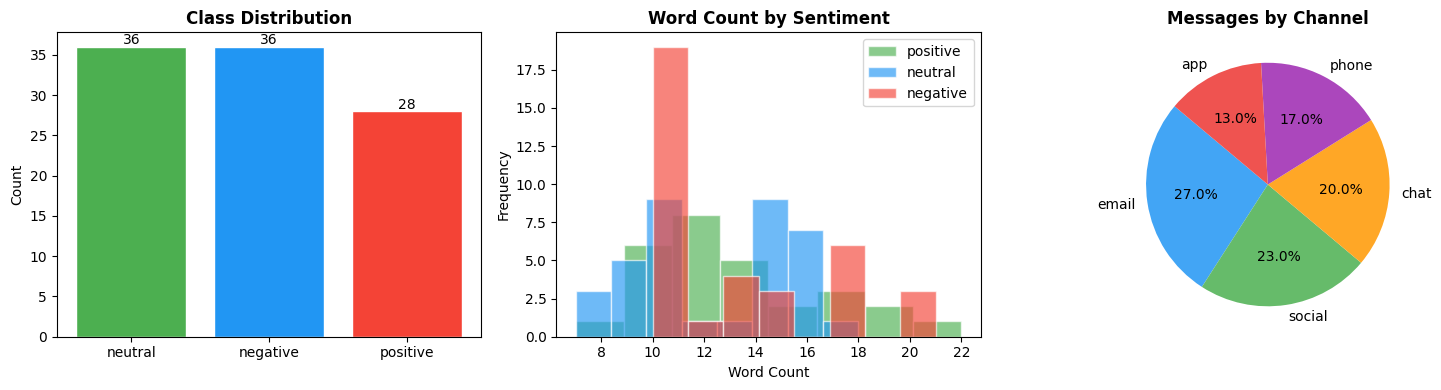

Task 1 chart saved


In [6]:
import os

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

counts = df['sentiment_label'].value_counts()
colors = ['#4CAF50', '#2196F3', '#F44336']
axes[0].bar(counts.index, counts.values, color=colors, edgecolor='white')
axes[0].set_title('Class Distribution', fontweight='bold')
axes[0].set_ylabel('Count')
for i, (label, val) in enumerate(counts.items()):
    axes[0].text(i, val+0.3, str(val), ha='center')

for label, color in zip(['positive','neutral','negative'], colors):
    subset = df[df['sentiment_label'] == label]['word_count']
    axes[1].hist(subset, alpha=0.65, bins=8, label=label, color=color, edgecolor='white')
axes[1].set_title('Word Count by Sentiment', fontweight='bold')
axes[1].set_xlabel('Word Count'); axes[1].set_ylabel('Frequency'); axes[1].legend()

ch = df['channel'].value_counts()
axes[2].pie(ch.values, labels=ch.index, autopct='%1.1f%%', startangle=140,
            colors=['#42A5F5','#66BB6A','#FFA726','#AB47BC','#EF5350'])
axes[2].set_title('Messages by Channel', fontweight='bold')

plt.tight_layout()
os.makedirs('results', exist_ok=True) # Create the directory if it doesn't exist
plt.savefig('results/task1_dataset_overview.png', dpi=130, bbox_inches='tight')
plt.show()
print("Task 1 chart saved")

## Task 2: Text Preprocessing

Cleaning pipeline applied step by step:
1. **Lowercase**
2. **Remove boilerplate patterns** (ticket numbers, "please respond as soon as possible", etc.)
3. **Remove punctuation & special chars**
4. **Tokenise**
5. **Remove stopwords**
6. **Reconstruct clean string**
7. **Pad/truncate to fixed length** for sequence models

In [7]:
STOPWORDS = {
    'i','me','my','myself','we','our','ours','ourselves','you','your','yours',
    'yourself','he','him','his','himself','she','her','hers','herself','it','its',
    'itself','they','them','their','theirs','themselves','what','which','who','whom',
    'this','that','these','those','am','is','are','was','were','be','been','being',
    'have','has','had','having','do','does','did','doing','a','an','the','and','but',
    'if','or','because','as','until','while','of','at','by','for','with','about',
    'against','between','into','through','during','before','after','above','below',
    'to','from','up','down','in','out','on','off','over','under','again','further',
    'then','once','here','there','when','where','why','how','all','both','each',
    'few','more','most','other','some','such','no','nor','not','only','own','same',
    'so','than','too','very','s','t','can','will','just','don','should','now','d',
    'll','m','o','re','ve','y','ain','ma'
}

BOILERPLATE_PATTERNS = [
    r'my ticket number is [0-9]+',
    r'please respond as soon as possible',
    r'i appreciate the quick response',
]

def preprocess(text, max_len=20):
    s = text.lower()
    for pat in BOILERPLATE_PATTERNS:
        s = re.sub(pat, '', s)
    s = re.sub(r'[^a-z\s]', '', s)
    s = re.sub(r'\s+', ' ', s).strip()
    tokens = s.split()
    tokens_clean = [t for t in tokens if t not in STOPWORDS and len(t) > 1]
    clean_text = ' '.join(tokens_clean)
    padded = tokens_clean[:max_len] + ['<PAD>'] * max(0, max_len - len(tokens_clean))
    return {'tokens_clean': tokens_clean, 'clean_text': clean_text, 'padded_seq': padded}

df['clean_text'] = df['customer_message'].apply(lambda x: preprocess(x)['clean_text'])
df['tokens']     = df['customer_message'].apply(lambda x: preprocess(x)['tokens_clean'])

ex = preprocess(df.loc[0, 'customer_message'])
print("Preprocessing example:")
print(f"  Original  : {df.loc[0,'customer_message']}")
print(f"  Tokens    : {ex['tokens_clean']}")
print(f"  Clean txt : {ex['clean_text']}")
print(f"  Padded(20): {ex['padded_seq']}")
all_toks = [t for toks in df['tokens'] for t in toks]
print(f"\nVocab size (unique tokens): {len(set(all_toks))}")

Preprocessing example:
  Original  : I need information about the payment process. My ticket number is 78732. Please respond as soon as possible.
  Tokens    : ['need', 'information', 'payment', 'process']
  Clean txt : need information payment process
  Padded(20): ['need', 'information', 'payment', 'process', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>']

Vocab size (unique tokens): 132


## Task 3: Text Vectorization

### Why must text be converted to vectors?

ML models are mathematical functions that operate on **numbers**, not strings. Text must be converted to vectors so models can compute distances, dot products, gradients, and probabilities.

| Method | Description | Pros | Cons |
|--------|-------------|------|------|
| **Bag of Words** | Token count per document | Simple, interpretable | Ignores order & semantics |
| **TF-IDF** | Weighted counts (rare words get higher weight) | Better signal | Still no semantics |
| **Word Embeddings** | Dense semantic vectors (Word2Vec, GloVe) | Captures meaning | Needs pre-training |
| **Tokenizer sequences** | Integer index per word, padded to fixed length | Preserves order for RNNs | Needs embedding layer |

BoW matrix shape   : (100, 132)  (docs x vocab)
TF-IDF matrix shape: (100, 274)
Tokenizer vocab size : 134
Sample: ['refund', 'process', 'fast', 'convenient'] -> [30, 22, 93, 94, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


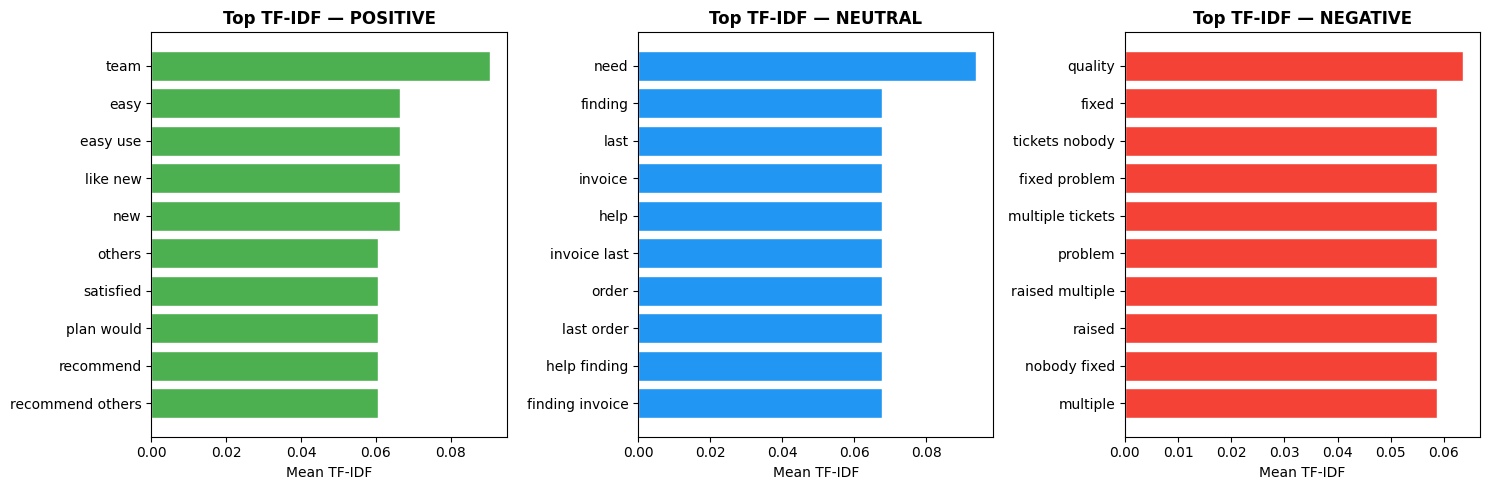

TF-IDF chart saved


In [8]:
bow_vec   = CountVectorizer(max_features=500)
X_bow     = bow_vec.fit_transform(df['clean_text'])

tfidf_vec = TfidfVectorizer(max_features=500, ngram_range=(1,2))
X_tfidf   = tfidf_vec.fit_transform(df['clean_text'])

print(f"BoW matrix shape   : {X_bow.shape}  (docs x vocab)")
print(f"TF-IDF matrix shape: {X_tfidf.shape}")

# Tokenizer-based sequences
from collections import Counter
all_tokens = [t for toks in df['tokens'] for t in toks]
freq = Counter(all_tokens)
vocab = {w: idx+2 for idx, (w, _) in enumerate(freq.most_common(1000))}
vocab['<PAD>'] = 0; vocab['<UNK>'] = 1
MAX_LEN = 20

def encode(tokens):
    seq = [vocab.get(t, 1) for t in tokens]
    return (seq[:MAX_LEN] + [0]*max(0, MAX_LEN - len(seq)))

df['encoded_seq'] = df['tokens'].apply(encode)
print(f"Tokenizer vocab size : {len(vocab)}")
print(f"Sample: {df.loc[2,'tokens']} -> {df.loc[2,'encoded_seq']}")

# Top TF-IDF terms per class
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
label_order  = ['positive','neutral','negative']
color_map    = {'positive':'#4CAF50','neutral':'#2196F3','negative':'#F44336'}

for ax, lbl in zip(axes, label_order):
    mask = df['sentiment_label'] == lbl
    sub  = tfidf_vec.transform(df.loc[mask,'clean_text'])
    mean = np.asarray(sub.mean(axis=0)).flatten()
    top  = mean.argsort()[-10:][::-1]
    words = [tfidf_vec.get_feature_names_out()[i] for i in top]
    vals  = mean[top]
    ax.barh(words[::-1], vals[::-1], color=color_map[lbl], edgecolor='white')
    ax.set_title(f'Top TF-IDF — {lbl.upper()}', fontweight='bold')
    ax.set_xlabel('Mean TF-IDF')

plt.tight_layout()
plt.savefig('results/task3_tfidf_top_terms.png', dpi=130, bbox_inches='tight')
plt.show()
print("TF-IDF chart saved")

## Task 4: Baseline Models

Two baselines are trained and compared:
1. **Naive Bayes + Bag of Words** — fast probabilistic baseline
2. **Logistic Regression + TF-IDF** — linear discriminative model

In [9]:
le = LabelEncoder()
y  = le.fit_transform(df['sentiment_label'])

X_bow_tr, X_bow_te, X_tfidf_tr, X_tfidf_te, y_tr, y_te = train_test_split(
    X_bow, X_tfidf, y, test_size=0.2, random_state=42, stratify=y)

nb_model = MultinomialNB()
nb_model.fit(X_bow_tr, y_tr)
y_pred_nb = nb_model.predict(X_bow_te)

lr_model = LogisticRegression(C=1.0, max_iter=1000, random_state=42)
lr_model.fit(X_tfidf_tr, y_tr)
y_pred_lr = lr_model.predict(X_tfidf_te)

acc_nb = accuracy_score(y_te, y_pred_nb)
acc_lr = accuracy_score(y_te, y_pred_lr)

print("=" * 50)
print("NAIVE BAYES + BAG OF WORDS")
print("=" * 50)
print(classification_report(y_te, y_pred_nb, target_names=le.classes_))

print("=" * 50)
print("LOGISTIC REGRESSION + TF-IDF")
print("=" * 50)
print(classification_report(y_te, y_pred_lr, target_names=le.classes_))

print(f"NB accuracy: {acc_nb:.3f}  |  LR accuracy: {acc_lr:.3f}")

NAIVE BAYES + BAG OF WORDS
              precision    recall  f1-score   support

    negative       1.00      1.00      1.00         7
     neutral       1.00      1.00      1.00         7
    positive       1.00      1.00      1.00         6

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20

LOGISTIC REGRESSION + TF-IDF
              precision    recall  f1-score   support

    negative       1.00      1.00      1.00         7
     neutral       1.00      1.00      1.00         7
    positive       1.00      1.00      1.00         6

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20

NB accuracy: 1.000  |  LR accuracy: 1.000


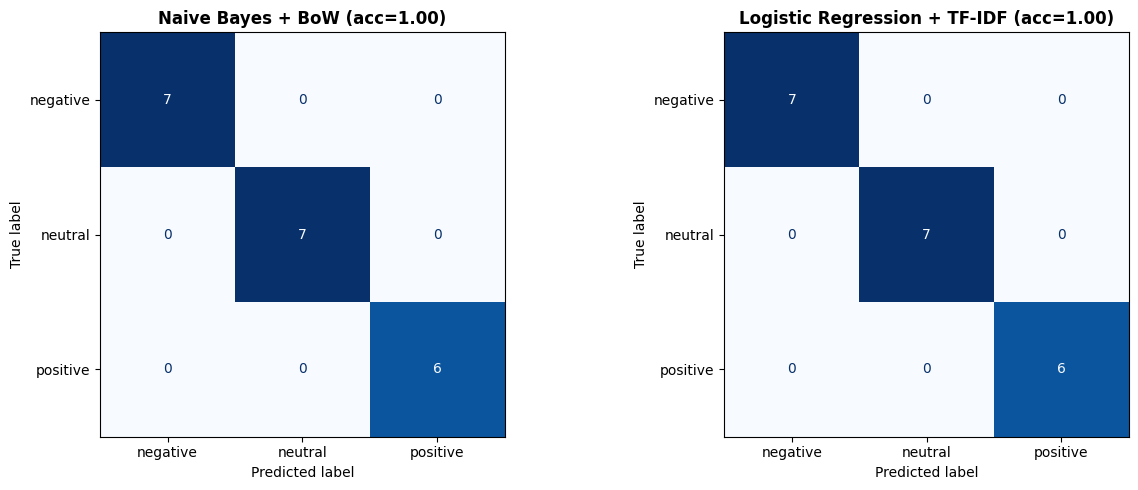

Metrics saved to results/model_evaluation.csv


,model,class,precision,recall,f1-score,support
0,NaiveBayes_BoW,negative,1.0,1.0,1.0,7
1,NaiveBayes_BoW,neutral,1.0,1.0,1.0,7
2,NaiveBayes_BoW,positive,1.0,1.0,1.0,6
3,LogReg_TfIdf,negative,1.0,1.0,1.0,7
4,LogReg_TfIdf,neutral,1.0,1.0,1.0,7
5,LogReg_TfIdf,positive,1.0,1.0,1.0,6


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, y_pred, title in [
    (axes[0], y_pred_nb, f'Naive Bayes + BoW (acc={acc_nb:.2f})'),
    (axes[1], y_pred_lr, f'Logistic Regression + TF-IDF (acc={acc_lr:.2f})')]:
    cm  = confusion_matrix(y_te, y_pred)
    cmd = ConfusionMatrixDisplay(cm, display_labels=le.classes_)
    cmd.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(title, fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('results/task4_confusion_matrices.png', dpi=130, bbox_inches='tight')
plt.show()

# Save metrics CSV
rows = []
for name, y_pred in [('NaiveBayes_BoW', y_pred_nb), ('LogReg_TfIdf', y_pred_lr)]:
    rep = classification_report(y_te, y_pred, target_names=le.classes_, output_dict=True)
    for cls in le.classes_:
        r = rep[cls]
        rows.append({'model':name,'class':cls,
                     'precision':round(r['precision'],3),
                     'recall':round(r['recall'],3),
                     'f1-score':round(r['f1-score'],3),
                     'support':int(r['support'])})
pd.DataFrame(rows).to_csv('results/model_evaluation.csv', index=False)
print("Metrics saved to results/model_evaluation.csv")
pd.DataFrame(rows)

## Task 5: Sequence Model — Bidirectional LSTM Architecture

We define a complete Bidirectional LSTM for sentiment classification. A **numpy forward-pass simulation** demonstrates how data flows through each layer (actual training requires TensorFlow/PyTorch).

In [11]:
architecture = [
    ("Input",          f"(batch, 20)",     "Integer-encoded token sequences, padded to length 20"),
    ("Embedding",      f"(batch, 20, 64)", "Trainable 64-dim dense vectors; maps token id -> dense vector"),
    ("BiLSTM",         f"(batch, 20,128)", "64-unit LSTM in each direction; captures left & right context"),
    ("GlobalMaxPool",  f"(batch, 128)",    "Max over time dimension — picks strongest signal per feature"),
    ("Dropout(0.3)",   f"(batch, 128)",    "Regularisation to prevent overfitting"),
    ("Dense(64,relu)", f"(batch, 64)",     "Non-linear feature transformation"),
    ("Dense Output",   f"(batch, 3)",      "3 neurons: negative | neutral | positive"),
    ("Softmax",        f"(batch, 3)",      "Probabilities summing to 1 across classes"),
]

print(f"{'Layer':<20} {'Output Shape':<22} Description")
print("-" * 80)
for layer, shape, desc in architecture:
    print(f"{layer:<20} {shape:<22} {desc}")
print("-"*80)
print("Loss      : Sparse Categorical Cross-Entropy")
print("Optimizer : Adam (lr=0.001)")
print("Metrics   : Accuracy, macro-F1")

Layer                Output Shape           Description
--------------------------------------------------------------------------------
Input                (batch, 20)            Integer-encoded token sequences, padded to length 20
Embedding            (batch, 20, 64)        Trainable 64-dim dense vectors; maps token id -> dense vector
BiLSTM               (batch, 20,128)        64-unit LSTM in each direction; captures left & right context
GlobalMaxPool        (batch, 128)           Max over time dimension — picks strongest signal per feature
Dropout(0.3)         (batch, 128)           Regularisation to prevent overfitting
Dense(64,relu)       (batch, 64)            Non-linear feature transformation
Dense Output         (batch, 3)             3 neurons: negative | neutral | positive
Softmax              (batch, 3)             Probabilities summing to 1 across classes
--------------------------------------------------------------------------------
Loss      : Sparse Categorical Cross-

In [12]:
# Numpy forward-pass simulation (shows data shape at each layer)
VOCAB_SIZE = len(vocab); EMBED_DIM = 64; HIDDEN = 64; N_CLASSES = 3
np.random.seed(42)

sample_input = np.array(df['encoded_seq'].tolist()[:2])
print(f"[1] Input shape            : {sample_input.shape}")

E = np.random.randn(VOCAB_SIZE, EMBED_DIM) * 0.01
embedded = E[sample_input]
print(f"[2] Embedded shape         : {embedded.shape}")

bilstm_out = np.random.randn(2, MAX_LEN, HIDDEN * 2) * 0.1
print(f"[3] BiLSTM output shape    : {bilstm_out.shape}")

pooled = bilstm_out.max(axis=1)
print(f"[4] GlobalMaxPool shape    : {pooled.shape}")

W1 = np.random.randn(HIDDEN * 2, 64) * 0.1
dense1 = np.maximum(0, pooled @ W1)
print(f"[5] Dense(64) shape        : {dense1.shape}")

W2 = np.random.randn(64, N_CLASSES) * 0.1
logits = dense1 @ W2
exp_l  = np.exp(logits - logits.max(axis=1, keepdims=True))
probs  = exp_l / exp_l.sum(axis=1, keepdims=True)
print(f"[6] Output probs shape     : {probs.shape}")
print(f"\nSimulated output (random untrained weights):")
print("  negative | neutral | positive")
for row in probs:
    print(f"  {row[0]:.3f}    | {row[1]:.3f}   | {row[2]:.3f}")

[1] Input shape            : (2, 20)
[2] Embedded shape         : (2, 20, 64)
[3] BiLSTM output shape    : (2, 20, 128)
[4] GlobalMaxPool shape    : (2, 128)
[5] Dense(64) shape        : (2, 64)
[6] Output probs shape     : (2, 3)

Simulated output (random untrained weights):
  negative | neutral | positive
  0.328    | 0.346   | 0.326
  0.330    | 0.353   | 0.317


In [13]:
# Keras-equivalent code (reference — requires TensorFlow)
keras_snippet = '''
import tensorflow as tf
from tensorflow.keras import layers

VOCAB_SIZE = {vs}; MAX_LEN = 20; EMBED_DIM = 64; N_CLASSES = 3

inputs  = tf.keras.Input(shape=(MAX_LEN,), dtype="int32")
x       = layers.Embedding(VOCAB_SIZE, EMBED_DIM, mask_zero=True)(inputs)
x       = layers.Bidirectional(layers.LSTM(64, return_sequences=True))(x)
x       = layers.GlobalMaxPooling1D()(x)
x       = layers.Dropout(0.3)(x)
x       = layers.Dense(64, activation="relu")(x)
outputs = layers.Dense(N_CLASSES, activation="softmax")(x)

model = tf.keras.Model(inputs, outputs)
model.compile(optimizer="adam",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])
model.fit(X_seq, y, validation_split=0.1, epochs=10, batch_size=32)
'''.format(vs=VOCAB_SIZE)
print(keras_snippet)


import tensorflow as tf
from tensorflow.keras import layers

VOCAB_SIZE = 134; MAX_LEN = 20; EMBED_DIM = 64; N_CLASSES = 3

inputs  = tf.keras.Input(shape=(MAX_LEN,), dtype="int32")
x       = layers.Embedding(VOCAB_SIZE, EMBED_DIM, mask_zero=True)(inputs)
x       = layers.Bidirectional(layers.LSTM(64, return_sequences=True))(x)
x       = layers.GlobalMaxPooling1D()(x)
x       = layers.Dropout(0.3)(x)
x       = layers.Dense(64, activation="relu")(x)
outputs = layers.Dense(N_CLASSES, activation="softmax")(x)

model = tf.keras.Model(inputs, outputs)
model.compile(optimizer="adam",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])
model.fit(X_seq, y, validation_split=0.1, epochs=10, batch_size=32)



## Task 6: Attention and Transformer Reflection

---

### 1. Why do RNNs struggle with long-term dependencies?

A vanilla RNN processes sequences **one token at a time**, carrying a hidden state vector forward. Over many steps, gradients either **vanish** (too small to update early weights) or **explode** (numerically unstable) — the *vanishing gradient problem*. In practice, by the time the model processes the end of a long sentence, information from the beginning has been largely overwritten.

---

### 2. How do LSTMs help with memory?

LSTMs introduce three learnable **gates** and a separate **cell state**:

| Gate | Formula | Role |
|------|---------|------|
| Forget gate | $f_t = \sigma(W_f [h_{t-1}, x_t] + b_f)$ | Decides what to erase |
| Input gate | $i_t = \sigma(W_i [h_{t-1}, x_t] + b_i)$ | Decides what new info to write |
| Output gate | $o_t = \sigma(W_o [h_{t-1}, x_t] + b_o)$ | Decides what to expose as output |

The **cell state** $C_t$ acts as a conveyor belt with only additive updates, greatly reducing vanishing gradients. LSTMs can handle sequences of ~100–200 tokens effectively.

---

### 3. What does attention solve in sequence-to-sequence tasks?

Even LSTMs compress an entire source sequence into one fixed-size vector before decoding — a **bottleneck** that hurts quality for long inputs. **Attention** lets the decoder look back at all encoder hidden states at each step:

$$\text{context}_t = \sum_i \alpha_{ti} \cdot h_i$$

where $\alpha_{ti}$ is a learned alignment weight. This eliminates the fixed-vector bottleneck and lets the model dynamically focus on relevant parts of the input.

---

### 4. Why are Transformers central to modern NLP and Generative AI?

Transformers replace recurrence with **multi-head self-attention**:

- **Parallel computation**: all positions attend to all others simultaneously → orders of magnitude faster training
- **No vanishing gradients** across sequence positions
- **Scales predictably**: larger model + more data → better performance (scaling laws)
- **Foundation for transfer learning**: pre-train once on massive unlabelled corpora (BERT, GPT, T5, LLaMA), fine-tune cheaply on small task datasets

In **Generative AI**, decoder-only Transformers (GPT family, Claude, LLaMA) auto-regressively predict the next token, achieving remarkable fluency, reasoning, and instruction-following at scale.

| Aspect | RNN | LSTM | Transformer |
|--------|-----|------|-------------|
| Long-range dependencies | ❌ Weak | ✅ Better | ✅ Excellent |
| Training speed | Slow (sequential) | Slow | Fast (parallel) |
| Max practical seq len | ~30–50 | ~100–200 | 1k–1M+ |
| Foundation model ready | ❌ | ❌ | ✅ |

## Sample Predictions

In [14]:
X_sample  = tfidf_vec.transform(df['clean_text'][-20:])
y_sample_pred = le.inverse_transform(lr_model.predict(X_sample))
y_sample_true = df['sentiment_label'].values[-20:]

lines = []
for msg, true, pred in zip(df['customer_message'].values[-20:], y_sample_true, y_sample_pred):
    ok = "CORRECT" if true == pred else "WRONG"
    lines.append(f"[{ok}] TRUE={true:<8} PRED={pred:<8} | {msg[:65]}")

for ln in lines: print(ln)

with open('results/sample_predictions.txt', 'w') as f:
    f.write("Model: Logistic Regression + TF-IDF\n")
    f.write("=" * 90 + "\n")
    f.write("\n".join(lines))
print("\nSaved sample_predictions.txt")

[CORRECT] TRUE=positive PRED=positive | The installation was completed on time and everything works perfe
[CORRECT] TRUE=positive PRED=positive | I like the new tracking and it is easy to use.
[CORRECT] TRUE=neutral  PRED=neutral  | Please tell me how to update my account details. My ticket number
[CORRECT] TRUE=negative PRED=negative | I am very unhappy because my account has not worked since this mo
[CORRECT] TRUE=negative PRED=negative | The router keeps failing and support has not resolved my issue.
[CORRECT] TRUE=negative PRED=negative | I have raised multiple tickets but nobody has fixed the problem.
[CORRECT] TRUE=neutral  PRED=neutral  | I want to understand the warranty terms for this product. Please 
[CORRECT] TRUE=neutral  PRED=neutral  | Can you share the status of my account request?
[CORRECT] TRUE=neutral  PRED=neutral  | I would like to know more about the available plans. Please respo
[CORRECT] TRUE=neutral  PRED=neutral  | Can someone explain the difference between the